In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 
  
# data (as pandas dataframes) 
X = statlog_german_credit_data.data.features 
y = statlog_german_credit_data.data.targets 
  
# metadata 
print(statlog_german_credit_data.metadata) 
  
# variable information 
print(statlog_german_credit_data.variables) 

{'uci_id': 144, 'name': 'Statlog (German Credit Data)', 'repository_url': 'https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data', 'data_url': 'https://archive.ics.uci.edu/static/public/144/data.csv', 'abstract': 'This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1000, 'num_features': 20, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Other', 'Marital Status', 'Age', 'Occupation'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5NC77', 'creators': ['Hans Hofmann'], 'intro_paper': None, 'additional_info': {'summary': 'Two datasets are provided.  the original dataset, in the form provided by

**German Credit dataset**: This dataset classifies people described by a set of attributes as good or bad credit risks. 1 good 2 bad

**Attribute description** 

1. Status of existing checking account, in Deutsche Mark.
2. Duration in months.
3. Credit history (credits taken, paid back duly, delays, critical accounts).4. Purpose of the credit (car, television,...).
5. Credit amount.
6. Status of savings account/bonds, in Deutsche Mark.
7. Present employment, in number of years.
8. Installment rate in percentage of disposable income.
9. Personal status (married, single,...) and sex.
10. Other debtors / guarantors.
11. Present residence since X years.
12. Property (e.g. real estate).
13. Age in years.
14. Other installment plans (banks, stores).
15. Housing (rent, own,...).
16. Number of existing credits at this bank.
17. Job.
18. Number of people being liable to provide maintenance for.
19. Telephone (yes,no).
20. Foreign worker (yes,no).n worker (yes,no)

In [3]:
y

,class
0,1
1,2
2,1
3,1
4,2
...,...
995,1
996,1
997,1
998,2


In [4]:
X

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,4,A121,31,A143,A152,1,A172,1,A191,A201
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,4,A122,40,A143,A152,1,A174,1,A192,A201
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,4,A124,23,A143,A153,1,A173,1,A192,A201


# Exploratory analysis

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
X.dtypes

Attribute1     object
Attribute2      int64
Attribute3     object
Attribute4     object
Attribute5      int64
Attribute6     object
Attribute7     object
Attribute8      int64
Attribute9     object
Attribute10    object
Attribute11     int64
Attribute12    object
Attribute13     int64
Attribute14    object
Attribute15    object
Attribute16     int64
Attribute17    object
Attribute18     int64
Attribute19    object
Attribute20    object
dtype: object

In [8]:
data = pd.concat([y, X], axis=1)
data.head()

,class,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,...,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,1,A11,6,A34,A43,1169,A65,A75,4,A93,...,4,A121,67,A143,A152,2,A173,1,A192,A201
1,2,A12,48,A32,A43,5951,A61,A73,2,A92,...,2,A121,22,A143,A152,1,A173,1,A191,A201
2,1,A14,12,A34,A46,2096,A61,A74,2,A93,...,3,A121,49,A143,A152,1,A172,2,A191,A201
3,1,A11,42,A32,A42,7882,A61,A74,2,A93,...,4,A122,45,A143,A153,1,A173,2,A191,A201
4,2,A11,24,A33,A40,4870,A61,A73,3,A93,...,4,A124,53,A143,A153,2,A173,2,A191,A201


In [12]:
data['class'].value_counts() #1: good 2: bad

class
1    700
2    300
Name: count, dtype: int64

## continuous variables

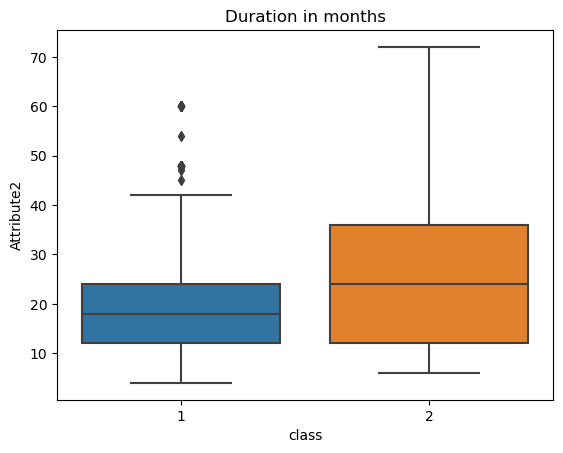

In [13]:
sns.boxplot(
    data=data,
    x='class',
    y='Attribute2'
)
#plt.ylim()
plt.title("Duration in months")
plt.show()

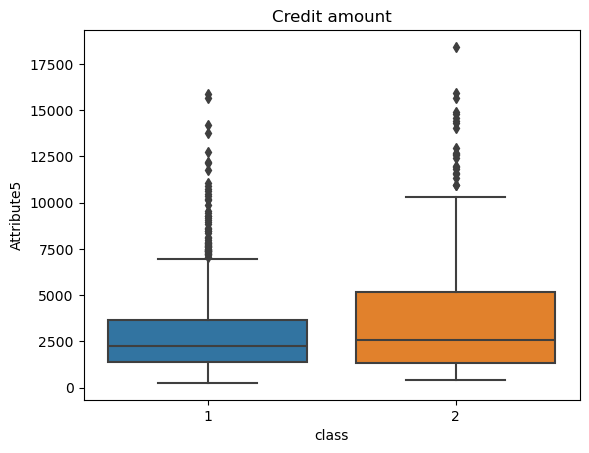

In [14]:
sns.boxplot(
    data=data,
    x='class',
    y='Attribute5'
)
#plt.ylim()
plt.title("Credit amount")
plt.show()

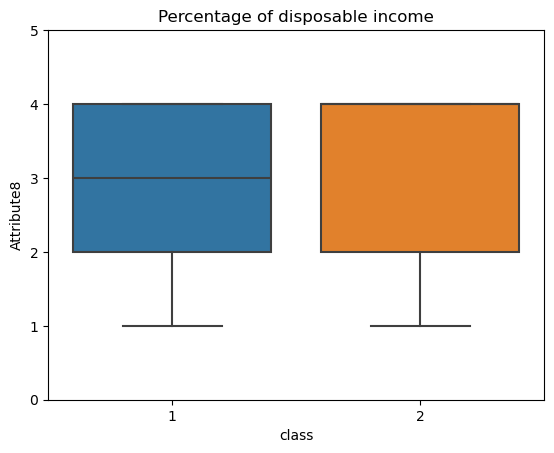

In [17]:
sns.boxplot(
    data=data,
    x='class',
    y='Attribute8'
)
plt.ylim(0,5)
plt.title("Percentage of disposable income")
plt.show()

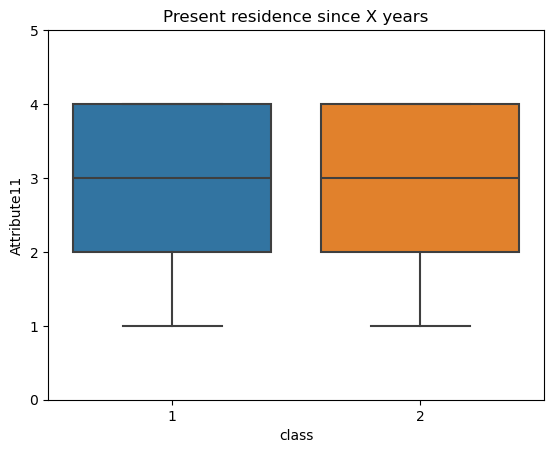

In [18]:
sns.boxplot(
    data=data,
    x='class',
    y='Attribute11'
)
plt.ylim(0,5)
plt.title("Present residence since X years")
plt.show()

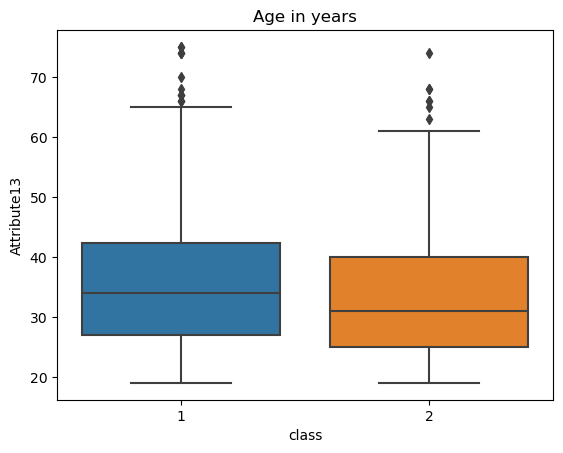

In [20]:
sns.boxplot(
    data=data,
    x='class',
    y='Attribute13'
)
#plt.ylim(0,5)
plt.title("Age in years")
plt.show()

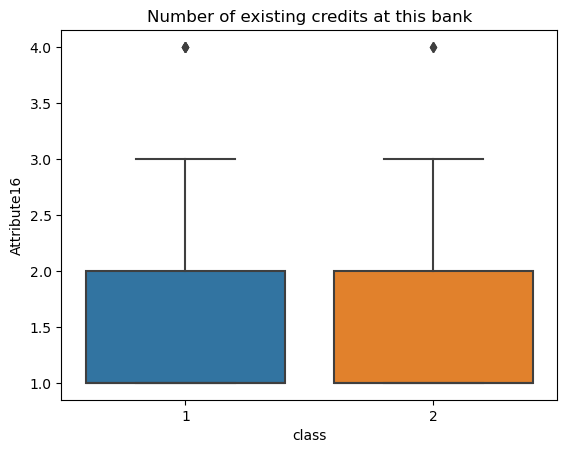

In [21]:
sns.boxplot(
    data=data,
    x='class',
    y='Attribute16'
)
#plt.ylim(0,5)
plt.title("Number of existing credits at this bank")
plt.show()

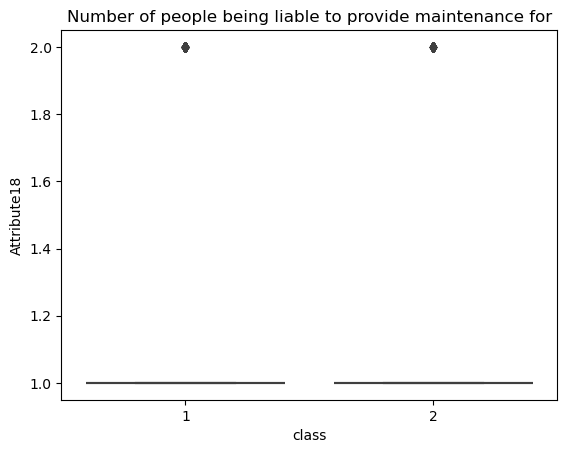

In [22]:
sns.boxplot(
    data=data,
    x='class',
    y='Attribute18'
)
#plt.ylim(0,5)
plt.title("Number of people being liable to provide maintenance for")
plt.show()

From the box plots it can be seen that there are significant differences in the age and duration in months of the loan.

## categorical variables

In [25]:
table_1 = pd.crosstab(data['Attribute1'], data['class'])
table_1_percent =table_1.div(table_1.sum(axis=0), axis=1) * 100
print(table_1_percent)

class               1          2
Attribute1                      
A11         19.857143  45.000000
A12         23.428571  35.000000
A13          7.000000   4.666667
A14         49.714286  15.333333


In [26]:
table_2 = pd.crosstab(data['Attribute3'], data['class'])
table_2_percent =table_2.div(table_2.sum(axis=0), axis=1) * 100
print(table_2_percent)

class               1          2
Attribute3                      
A30          2.142857   8.333333
A31          3.000000   9.333333
A32         51.571429  56.333333
A33          8.571429   9.333333
A34         34.714286  16.666667


In [27]:
table_3 = pd.crosstab(data['Attribute4'], data['class'])
table_3_percent =table_3.div(table_3.sum(axis=0), axis=1) * 100
print(table_3_percent)

class               1          2
Attribute4                      
A40         20.714286  29.666667
A41         12.285714   5.666667
A410         1.000000   1.666667
A42         17.571429  19.333333
A43         31.142857  20.666667
A44          1.142857   1.333333
A45          2.000000   2.666667
A46          4.000000   7.333333
A48          1.142857   0.333333
A49          9.000000  11.333333


In [28]:
table_4 = pd.crosstab(data['Attribute6'], data['class'])
table_4_percent =table_4.div(table_4.sum(axis=0), axis=1) * 100
print(table_4_percent)

class               1          2
Attribute6                      
A61         55.142857  72.333333
A62          9.857143  11.333333
A63          7.428571   3.666667
A64          6.000000   2.000000
A65         21.571429  10.666667


In [29]:
table_5 = pd.crosstab(data['Attribute7'], data['class'])
table_5_percent =table_5.div(table_5.sum(axis=0), axis=1) * 100
print(table_5_percent)

class               1          2
Attribute7                      
A71          5.571429   7.666667
A72         14.571429  23.333333
A73         33.571429  34.666667
A74         19.285714  13.000000
A75         27.000000  21.333333


In [30]:
table_6 = pd.crosstab(data['Attribute9'], data['class'])
table_6_percent =table_6.div(table_6.sum(axis=0), axis=1) * 100
print(table_6_percent)

class               1          2
Attribute9                      
A91          4.285714   6.666667
A92         28.714286  36.333333
A93         57.428571  48.666667
A94          9.571429   8.333333


In [35]:
table_7 = pd.crosstab(data['Attribute10'], data['class'])
table_7_percent =table_7.div(table_7.sum(axis=0), axis=1) * 100
print(table_7_percent)

class                1          2
Attribute10                      
A101         90.714286  90.666667
A102          3.285714   6.000000
A103          6.000000   3.333333


In [36]:
table_8 = pd.crosstab(data['Attribute12'], data['class'])
table_8_percent =table_8.div(table_8.sum(axis=0), axis=1) * 100
print(table_8_percent)

class                1          2
Attribute12                      
A121         31.714286  20.000000
A122         23.000000  23.666667
A123         32.857143  34.000000
A124         12.428571  22.333333


In [37]:
table_9 = pd.crosstab(data['Attribute14'], data['class'])
table_9_percent =table_9.div(table_9.sum(axis=0), axis=1) * 100
print(table_9_percent)

class                1          2
Attribute14                      
A141         11.714286  19.000000
A142          4.000000   6.333333
A143         84.285714  74.666667


In [38]:
table_10 = pd.crosstab(data['Attribute15'], data['class'])
table_10_percent =table_10.div(table_10.sum(axis=0), axis=1) * 100
print(table_10_percent)

class                1          2
Attribute15                      
A151         15.571429  23.333333
A152         75.285714  62.000000
A153          9.142857  14.666667


In [39]:
table_11 = pd.crosstab(data['Attribute17'], data['class'])
table_11_percent =table_11.div(table_11.sum(axis=0), axis=1) * 100
print(table_11_percent)

class                1          2
Attribute17                      
A171          2.142857   2.333333
A172         20.571429  18.666667
A173         63.428571  62.000000
A174         13.857143  17.000000


In [40]:
table_12 = pd.crosstab(data['Attribute19'], data['class'])
table_12_percent =table_11.div(table_12.sum(axis=0), axis=1) * 100
print(table_12_percent)

class                1          2
Attribute17                      
A171          2.142857   2.333333
A172         20.571429  18.666667
A173         63.428571  62.000000
A174         13.857143  17.000000


In [41]:
table_13 = pd.crosstab(data['Attribute20'], data['class'])
table_13_percent =table_13.div(table_13.sum(axis=0), axis=1) * 100
print(table_13_percent)

class                1          2
Attribute20                      
A201         95.285714  98.666667
A202          4.714286   1.333333


it is observed in the crosstabs that most of my categorical variables have a high correlation with credit risk based on the difference in proportions.

# Implementation of Models

For the credit risk rating dataset we will test classical models such as logistic regression or SVM, and also more complex models such as Random Forest, XGBoost or Gradient Boosting and at the end compare them and decide which one to choose.

### Logistic Regression

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_columns = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(), categorical_columns)],
    remainder='passthrough'  
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_log=pipeline.fit(X_train, y_train)
y_pred_log = pipeline.predict(X_test)

C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_log = precision_score(y_test, y_pred_log, average='binary')
recall_log = recall_score(y_test, y_pred_log, average='binary')
f1_log = f1_score(y_test, y_pred_log, average='binary')

print(f"Precisión: {precision_log}")
print(f"Recall: {recall_log}")
print(f"F1-score: {f1_log}")

Precisión: 0.8157894736842105
Recall: 0.8794326241134752
F1-score: 0.8464163822525597


In [9]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

scores_recall_log = cross_val_score(model_log, X, y, cv=10, scoring='recall')
scores_precision_log = cross_val_score(model_log, X, y, cv=10, scoring='precision')
scores_f1_log = cross_val_score(model_log, X, y, cv=10, scoring='f1')

C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example

In [64]:
print("Recall:", scores_recall_log.mean())
print("Precisión:", scores_precision_log.mean())
print("F1-score:", scores_f1_log.mean())

Recall: 0.8757142857142858
Precisión: 0.7912044403306253
F1-score: 0.8309497343006969


### Support Vector Machine (SVM)

In [67]:
from sklearn.svm import SVC

categorical_columns = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(), categorical_columns)],
    remainder='passthrough'  
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='linear')) #kernel: 'rbf', 'poly', 'sigmoid', 'linear'
])

model_SVM=pipeline.fit(X_train, y_train)
y_pred_SVM = pipeline.predict(X_test)

C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [71]:
precision_SVM = precision_score(y_test, y_pred_SVM, average='binary')
recall_SVM = recall_score(y_test, y_pred_SVM, average='binary')
f1_SVM = f1_score(y_test, y_pred_SVM, average='binary')

print(f"Precisión: {precision_SVM}")
print(f"Recall: {recall_SVM}")
print(f"F1-score: {f1_SVM}")

Precisión: 0.7682119205298014
Recall: 0.8226950354609929
F1-score: 0.7945205479452054


In [73]:
scores_recall_SVM = cross_val_score(model_SVM, X, y, cv=5, scoring='recall')
scores_precision_SVM = cross_val_score(model_SVM, X, y, cv=5, scoring='precision')
scores_f1_SVM = cross_val_score(model_SVM, X, y, cv=5, scoring='f1')

C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samp

In [74]:
print("Recall:", scores_recall_SVM.mean())
print("Precisión:", scores_precision_SVM.mean())
print("F1-score:", scores_f1_SVM.mean())

Recall: 0.8514285714285714
Precisión: 0.7998986920664402
F1-score: 0.8242355550180098


### Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier

categorical_columns = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(), categorical_columns)],
    remainder='passthrough'  
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_RF=pipeline.fit(X_train, y_train)
y_pred_RF = pipeline.predict(X_test)

C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\pipeline.py:405: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)


In [15]:
precision_RF = precision_score(y_test, y_pred_RF, average='binary')
recall_RF = recall_score(y_test, y_pred_RF, average='binary')
f1_RF = f1_score(y_test, y_pred_RF, average='binary')

print(f"Precisión: {precision_RF}")
print(f"Recall: {recall_RF}")
print(f"F1-score: {f1_RF}")

Precisión: 0.8136645962732919
Recall: 0.9290780141843972
F1-score: 0.8675496688741722


In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

scores_recall_RF = cross_val_score(model_RF, X, y, cv=5, scoring='recall')
scores_precision_RF = cross_val_score(model_RF, X, y, cv=5, scoring='precision')
scores_f1_RF = cross_val_score(model_RF, X, y, cv=5, scoring='f1')

C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\pipeline.py:405: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)
C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\pipeline.py:405: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)
C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\pipeline.py:405: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)
C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\pipeline.py:405: DataConversionWarning: A column-vector y was passed when a 1d array was expected. 

In [19]:
print("Recall:", scores_recall_RF.mean())
print("Precisión:", scores_precision_RF.mean())
print("F1-score:", scores_f1_RF.mean())

Recall: 0.9257142857142856
Precisión: 0.7818616037750228
F1-score: 0.8475060319803192


### XGBoost

In [43]:
import xgboost as xgb

y2 = y.replace({1: 1, 2: 0}) ##1: good 2: bad

X_train, X_test, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=42)

categorical_columns = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(), categorical_columns)],
    remainder='passthrough'  
)

model = xgb.XGBClassifier(
    objective='binary:logistic',  # Tarea de clasificación binaria
    eval_metric='auc',  # Métrica de evaluación para clasificación binaria
    use_label_encoder=False  # Evitar advertencias relacionadas con el codificador de etiquetas
)

# Crear el pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# Entrenar el modelo
model_XGB = pipeline.fit(X_train, y2_train)

# Hacer predicciones
y_pred_XGB = pipeline.predict(X_test)

C:\Users\Javier\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:10:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [45]:
precision_XGB = precision_score(y2_test, y_pred_XGB, average='binary')
recall_XGB = recall_score(y2_test, y_pred_XGB, average='binary')
f1_XGB = f1_score(y2_test, y_pred_XGB, average='binary')

print(f"Precisión: {precision_XGB}")
print(f"Recall: {recall_XGB}")
print(f"F1-score: {f1_XGB}")

Precisión: 0.8211920529801324
Recall: 0.8794326241134752
F1-score: 0.8493150684931506


In [47]:
scores_recall_XGB = cross_val_score(model_XGB, X, y2, cv=5, scoring='recall')
scores_precision_XGB = cross_val_score(model_XGB, X, y2, cv=5, scoring='precision')
scores_f1_XGB = cross_val_score(model_XGB, X, y2, cv=5, scoring='f1')

C:\Users\Javier\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:10:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\Javier\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:10:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\Javier\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:10:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\Javier\anaconda3\Lib\site-packa

In [49]:
print("Recall:", scores_recall_XGB.mean())
print("Precisión:", scores_precision_XGB.mean())
print("F1-score:", scores_f1_XGB.mean())

Recall: 0.872857142857143
Precisión: 0.7979771105492308
F1-score: 0.8334404150764938


### Gradient Boosting

In [53]:
from sklearn.ensemble import GradientBoostingClassifier

categorical_columns = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(), categorical_columns)],
    remainder='passthrough'  
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_GB = pipeline.fit(X_train, y_train)
y_pred_GB = pipeline.predict(X_test)

C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [55]:
precision_GB = precision_score(y_test, y_pred_GB, average='binary')
recall_GB = recall_score(y_test, y_pred_GB, average='binary')
f1_GB = f1_score(y_test, y_pred_GB, average='binary')

print(f"Precisión: {precision_GB}")
print(f"Recall: {recall_GB}")
print(f"F1-score: {f1_GB}")

Precisión: 0.8193548387096774
Recall: 0.900709219858156
F1-score: 0.8581081081081081


In [57]:
scores_recall_GB = cross_val_score(model_GB, X, y2, cv=5, scoring='recall')
scores_precision_GB = cross_val_score(model_GB, X, y2, cv=5, scoring='precision')
scores_f1_GB = cross_val_score(model_GB, X, y2, cv=5, scoring='f1')

C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:437: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example 

In [59]:
print("Recall:", scores_recall_XGB.mean())
print("Precisión:", scores_precision_XGB.mean())
print("F1-score:", scores_f1_XGB.mean())

Recall: 0.872857142857143
Precisión: 0.7979771105492308
F1-score: 0.8334404150764938


# Summary of Results

The following results of the cross-validation show that there is no great difference in F1-score between the models, and the choice of model may depend on the business objective, which in this case recall is a priority due to the need to correctly identify high-risk customers, so the best model would be Random Forest, since it has the highest recall.

XGBoost and Gradient Boosting are also very good options, as they offer a good balance between recall and accuracy. If the balance between the two is important or if a more interpretive model is sought, logistic regression could also be considered, although its recall is lower than Random Forest.

| Model | Recall | Precisión | F1-Score |
|:-----------:|:-----------:|:-----------:|:-----------:|
| Logistic Regression    | 87.57%    | 79.12%    | 83.09%    |
| Support Vector Machine (SVM)    | 85.14%    | 79.98%    | 82.42%    |
| Random Forest    | 92.57%    | 78.18%    | 84.75%    |
| XGBoost    | 87.28%    | 79.79%    | 83.34%    |
| Gradient Boosting    | 87.28%    | 79.79%    | 83.34%    |